In [ ]:
!pip install nltk -q

import pandas as pd
import numpy as np
import re
import joblib
import nltk
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df = pd.read_csv("/content/sentiment_real_reviews_1000.csv")

print("Original shape:", df.shape)
print(df.head())

Original shape: (1000, 2)
                                             reviews sentiment_label
0  Lol.... the only reason i bought this tablet w...        negative
1  Wish tablet was voice capable. Only problem wa...        negative
2  Alexa works great with music. Just wish you di...        positive
3  Led to more echo dots and significant home aut...         neutral
4  I purchased this after trying the Insignia 8" ...        positive


In [ ]:
df = df[["reviews", "sentiment_label"]].dropna()
df = df.rename(columns={"reviews": "text", "sentiment_label": "label"})

In [ ]:


def normalize_text(text):
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text

df["norm_text"] = df["text"].apply(normalize_text)

In [ ]:
print("Exact duplicate texts before removal:", df["norm_text"].duplicated().sum())
df = df.drop_duplicates(subset="norm_text").reset_index(drop=True)
print("Shape after duplicate removal:", df.shape)

Exact duplicate texts before removal: 0
Shape after duplicate removal: (1000, 3)


In [ ]:
label_words_pattern = r"\b(positive|negative|neutral|sarcastic|standard)\b"
contains_label_word = df["norm_text"].str.contains(label_words_pattern, regex=True)
print("Rows containing label words:", contains_label_word.sum())

df = df[~contains_label_word].reset_index(drop=True)
print("Shape after removing label-word rows:", df.shape)

Rows containing label words: 3
Shape after removing label-word rows: (997, 3)


/tmp/ipykernel_18599/1225612823.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_label_word = df["norm_text"].str.contains(label_words_pattern, regex=True)


In [ ]:
print("\nSentiment distribution:")
print(df["label"].value_counts())


Sentiment distribution:
label
neutral     333
negative    332
positive    332
Name: count, dtype: int64


In [ ]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, df.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
svm_sentiment = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        max_features=15000
    )),
    ("svm", LinearSVC())
])


In [ ]:
svm_sentiment.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=15000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('svm', LinearSVC())])

In [ ]:
y_pred = svm_sentiment.predict(X_test)

In [ ]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.885

Classification Report:

              precision    recall  f1-score   support

    negative       0.82      0.90      0.86        67
     neutral       0.87      0.81      0.84        67
    positive       0.97      0.95      0.96        66

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200


Confusion Matrix:

[[60  5  2]
 [13 54  0]
 [ 0  3 63]]


In [ ]:
cv_scores = cross_val_score(
    svm_sentiment,
    X,
    y,
    cv=5,
    scoring="f1_macro"
)

print("\nCross-validation F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())


Cross-validation F1 scores: [0.85080258 0.8691251  0.87330247 0.87996432 0.82539929]
Mean CV F1: 0.8597187513675575


In [ ]:
sample_reviews = [
    "This product is excellent and works perfectly. I am very happy with it.",
    "The product is okay, nothing special.",
    "Very disappointing item. It stopped working after two days."
]

sample_preds = svm_sentiment.predict(sample_reviews)
sample_scores = svm_sentiment.decision_function(sample_reviews)

print("\nCustom review predictions:")
for review, pred, score in zip(sample_reviews, sample_preds, sample_scores):
    print("Review:", review)
    print("Predicted sentiment:", pred)
    print("Decision scores:", score)
    print("-" * 60)



Custom review predictions:
Review: This product is excellent and works perfectly. I am very happy with it.
Predicted sentiment: positive
Decision scores: [-0.47755511 -0.89235822  0.37460057]
------------------------------------------------------------
Review: The product is okay, nothing special.
Predicted sentiment: negative
Decision scores: [-0.28998532 -0.41400445 -0.29194995]
------------------------------------------------------------
Review: Very disappointing item. It stopped working after two days.
Predicted sentiment: neutral
Decision scores: [-0.50688095  0.23399515 -0.72510694]
------------------------------------------------------------


In [ ]:
joblib.dump(svm_sentiment, "svm_sentiment_model.pkl")
print("\nSaved as svm_sentiment_model.pkl")


Saved as svm_sentiment_model.pkl


Now Trying for sarcasm prediction


In [ ]:
df = pd.read_csv("/content/sarcasm_mixed_reviews_1000.csv")

print("Original shape:", df.shape)
print(df.head())

Original shape: (1000, 4)
                                             reviews sentiment_label  \
0  What an annoying outcome: the tablet actually ...        positive   
1  So many products on the market. This by far is...         neutral   
2  Really easy to work with lots of extras. Good ...        positive   
3  A stunning display of modern engineering — thi...        negative   
4  Ever since I had my fire TV jail broken and pr...        negative   

       style     source  
0  sarcastic  generated  
1   standard       real  
2   standard       real  
3  sarcastic  generated  
4   standard       real  


In [ ]:
df = df[["reviews", "style", "sentiment_label"]].dropna()
df = df.rename(columns={"reviews": "text", "style": "label"})

In [ ]:
def normalize_text(text):
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text

df["norm_text"] = df["text"].apply(normalize_text)

In [ ]:
print("Exact duplicate texts before removal:", df["norm_text"].duplicated().sum())
df = df.drop_duplicates(subset="norm_text").reset_index(drop=True)
print("Shape after duplicate removal:", df.shape)

Exact duplicate texts before removal: 0
Shape after duplicate removal: (1000, 4)


In [ ]:
label_words_pattern = r"\b(positive|negative|neutral|sarcastic|standard)\b"
contains_label_word = df["norm_text"].str.contains(label_words_pattern, regex=True)
print("Rows containing label words:", contains_label_word.sum())

df = df[~contains_label_word].reset_index(drop=True)
print("Shape after removing label-word rows:", df.shape)

Rows containing label words: 2
Shape after removing label-word rows: (998, 4)


/tmp/ipykernel_18599/1225612823.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_label_word = df["norm_text"].str.contains(label_words_pattern, regex=True)


In [ ]:
print("\nSarcasm label distribution:")
print(df["label"].value_counts())

print("\nSentiment distribution in sarcasm dataset:")
print(df["sentiment_label"].value_counts())


Sarcasm label distribution:
label
sarcastic    500
standard     498
Name: count, dtype: int64

Sentiment distribution in sarcasm dataset:
sentiment_label
positive    334
neutral     333
negative    331
Name: count, dtype: int64


In [ ]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, df.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
svm_sarcasm = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        max_features=15000
    )),
    ("svm",LinearSVC())
])

In [ ]:
svm_sarcasm.fit(X_train, y_train)


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=15000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('svm', LinearSVC())])

In [ ]:
y_pred = svm_sarcasm.predict(X_test)

In [ ]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.99

Classification Report:

              precision    recall  f1-score   support

   sarcastic       0.98      1.00      0.99       100
    standard       1.00      0.98      0.99       100

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200


Confusion Matrix:

[[100   0]
 [  2  98]]


In [ ]:
cv_scores = cross_val_score(
    svm_sarcasm,
    X,
    y,
    cv=5,
    scoring="f1_macro"
)

print("\nCross-validation F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())



Cross-validation F1 scores: [1.         0.99499987 0.99499987 1.         1.        ]
Mean CV F1: 0.99799994999875


In [ ]:
sample_reviews = [
    "This product is fantastic and works perfectly.",
    "dissapointing charger. I thought it would stop working in one day, but is working absolutely fine.",
    "Absolutely brilliant. I love how it stopped working immediately.",
    "The product is average, not too bad and not too good."
]

sample_preds = svm_sarcasm.predict(sample_reviews)
sample_scores = svm_sarcasm.decision_function(sample_reviews)

print("\nCustom review predictions:")
for review, pred, score in zip(sample_reviews, sample_preds, sample_scores):
    print("Review:", review)
    print("Predicted style:", pred)
    print("Decision score:", score)
    print("-" * 60)


Custom review predictions:
Review: This product is fantastic and works perfectly.
Predicted style: standard
Decision score: 0.6777129249934591
------------------------------------------------------------
Review: dissapointing charger. I thought it would stop working in one day, but is working absolutely fine.
Predicted style: standard
Decision score: 0.1766643655159999
------------------------------------------------------------
Review: Absolutely brilliant. I love how it stopped working immediately.
Predicted style: sarcastic
Decision score: -0.20576669633150435
------------------------------------------------------------
Review: The product is average, not too bad and not too good.
Predicted style: standard
Decision score: 0.5134961673720816
------------------------------------------------------------


In [ ]:
joblib.dump(svm_sarcasm, "svm_sarcasm_model.pkl")
print("\nSaved as svm_sarcasm_model.pkl")


Saved as svm_sarcasm_model.pkl


Checking most common words and plotting its graph

In [ ]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return words

df["clean_words"] = df["text"].apply(clean_text)

sarcastic_words = []
standard_words = []

for _, row in df.iterrows():
    if row["label"] == "sarcastic":
        sarcastic_words.extend(row["clean_words"])
    else:
        standard_words.extend(row["clean_words"])

sarcastic_counter = Counter(sarcastic_words)
standard_counter = Counter(standard_words)

top_sarcastic = sarcastic_counter.most_common(15)
top_standard = standard_counter.most_common(15)

print("\nTop sarcastic words:", top_sarcastic)
print("\nTop standard words:", top_standard)


Top sarcastic words: [('use', 148), ('tablet', 124), ('keeps', 115), ('drama', 77), ('without', 75), ('almost', 74), ('made', 70), ('job', 63), ('basic', 61), ('speaker', 60), ('complain', 58), ('daily', 56), ('exactly', 52), ('kindle', 52), ('dramatic', 52)]

Top standard words: [('tablet', 140), ('great', 88), ('use', 86), ('fire', 83), ('kindle', 80), ('amazon', 77), ('price', 74), ('bought', 72), ('like', 68), ('one', 60), ('get', 58), ('slow', 51), ('problem', 49), ('works', 49), ('love', 49)]


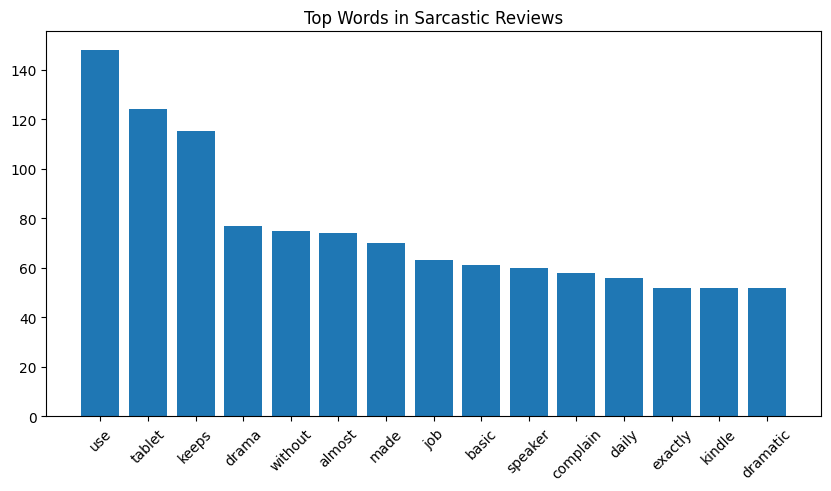

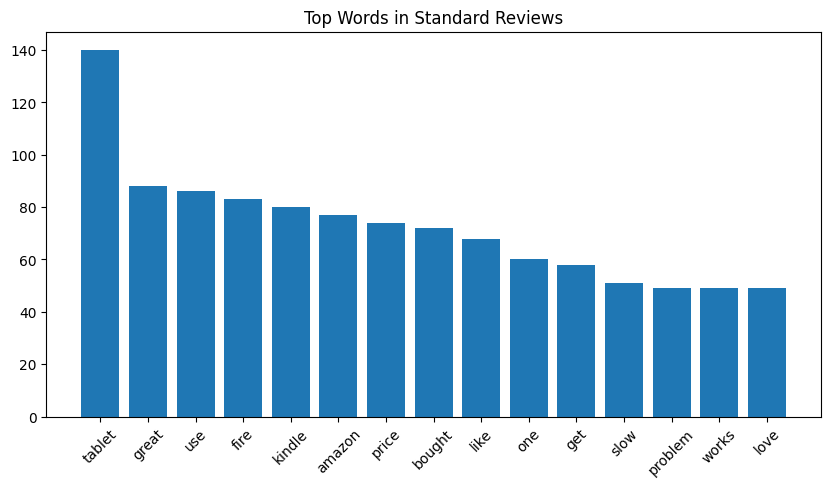

In [ ]:
def plot_words(word_list, title):
    words, counts = zip(*word_list)
    plt.figure(figsize=(10,5))
    plt.bar(words, counts)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

plot_words(top_sarcastic, "Top Words in Sarcastic Reviews")
plot_words(top_standard, "Top Words in Standard Reviews")

In [ ]:

vectorizer = svm_sarcasm.named_steps["tfidf"]
svm = svm_sarcasm.named_steps["svm"]

feature_names = vectorizer.get_feature_names_out()
coefficients = svm.coef_[0]

top_positive = np.argsort(coefficients)[-15:]
top_negative = np.argsort(coefficients)[:15]

print("\nTop STANDARD words (SVM):")
for i in reversed(top_positive):
    print(feature_names[i], coefficients[i])

print("\nTop SARCASTIC words (SVM):")
for i in top_negative:
    print(feature_names[i], coefficients[i])


Top STANDARD words (SVM):
great 0.787881299853121
amazon 0.7807827364041409
problem 0.6398518922376831
bought 0.5850715720642924
price 0.5686902471140303
loves 0.5438718589529956
bad 0.495336814396546
tv 0.4871588495515226
alexa 0.48048755990497044
purchased 0.46638985152000795
apps 0.4659319576443192
kids 0.45906085485063386
slow 0.45210013955673206
reading 0.4501396687673855
nice 0.43645550948327405

Top SARCASTIC words (SVM):
exactly -0.9713228987333306
keeps -0.9300253753559761
just love -0.9058423751201975
dramatic -0.8941742844899824
average -0.8455573191027195
job -0.8152747991623248
felt -0.7804998687730228
drama -0.7730182769837398
memorable -0.7444469633398662
complain -0.7406621376990508
functionality -0.7383261312065611
way -0.7339491133491499
just -0.7244736634034826
actually -0.7025941311966214
honestly -0.6961000011871922
